<a href="https://colab.research.google.com/github/Anantask/Mumbai-Housing-Price-Analysis/blob/main/Mumbai_Housing_Price_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### **Importing and Loading Datasets**

In [ ]:
url='https://raw.githubusercontent.com/Anantask/Mumbai-Housing-Price-Analysis/refs/heads/main/housing_price_mumbai.csv'

### **Data Cleaning and EDA**

In [ ]:
df=pd.read_csv(url)
df.head()

,location,bhk,bath,total_sqft,price_per_sqft,price_lakhs,balcony,society_type,availability
0,Juhu,1,1.0,496,36571,181.39,2.0,Luxury,1 year
1,Andheri West,1,1.0,494,28069,138.66,2.0,Premium,1 year
2,Goregaon East,2,1.0,1137,20108,228.63,2.0,Affordable,6 months
3,Borivali West,1,1.0,737,15418,113.63,0.0,Mid-Range,6 months
4,Kurla West,2,2.0,1327,15196,201.65,1.0,Luxury,6 months


In [ ]:
df.tail()

,location,bhk,bath,total_sqft,price_per_sqft,price_lakhs,balcony,society_type,availability
495,Vikhroli,4,NaN,2020,16042,324.05,0.0,Luxury,6 months
496,Kurla West,3,2.0,1411,13022,183.74,0.0,Luxury,Ready To Move
497,Kharghar,3,3.0,1809,10674,193.09,0.0,Affordable,6 months
498,Borivali West,4,3.0,2283,17506,399.66,NaN,Affordable,Ready To Move
499,Panvel,3,2.0,1444,9290,134.15,1.0,Mid-Range,6 months


In [ ]:
df.shape

(500, 9)

In [ ]:
df.describe()

,bhk,bath,total_sqft,price_per_sqft,price_lakhs,balcony
count,500.000000,480.000000,500.000000,500.000000,500.000000,485.000000
mean,2.300000,1.960417,1253.334000,20772.750000,258.921498,1.014433
std,1.031566,0.954331,563.378855,9628.940185,171.526833,0.798887
min,1.000000,1.000000,331.000000,7103.000000,29.460000,0.000000
25%,1.000000,1.000000,722.750000,13495.750000,137.345000,0.000000
50%,2.000000,2.000000,1233.500000,17974.500000,211.655000,1.000000
75%,3.000000,3.000000,1681.250000,26172.750000,328.640000,2.000000
max,4.000000,4.000000,2761.000000,43891.000000,902.130000,2.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        500 non-null    object 
 1   bhk             500 non-null    int64  
 2   bath            480 non-null    float64
 3   total_sqft      500 non-null    int64  
 4   price_per_sqft  500 non-null    int64  
 5   price_lakhs     500 non-null    float64
 6   balcony         485 non-null    float64
 7   society_type    500 non-null    object 
 8   availability    500 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 35.3+ KB


In [ ]:
df.isnull().sum()

,0
location,0
bhk,0
bath,20
total_sqft,0
price_per_sqft,0
price_lakhs,0
balcony,15
society_type,0
availability,0


In [ ]:
# sns.boxplot(data=df)
# plt.show()

In [ ]:
df=df.fillna(df.mean(numeric_only=True))

In [ ]:
df.isnull().sum()

,0
location,0
bhk,0
bath,0
total_sqft,0
price_per_sqft,0
price_lakhs,0
balcony,0
society_type,0
availability,0


## **Feature Engineering**

In [ ]:
df['is_expensive'] = df['price_per_sqft'].apply(lambda x: 'High' if x > 20000 else 'Low')
df.head(2)

,location,bhk,bath,total_sqft,price_per_sqft,price_lakhs,balcony,society_type,availability,is_expensive
0,Juhu,1,1.0,496,36571,181.39,2.0,Luxury,1 year,High
1,Andheri West,1,1.0,494,28069,138.66,2.0,Premium,1 year,High


## **Visualization**


<Axes: xlabel='price_lakhs', ylabel='Count'>

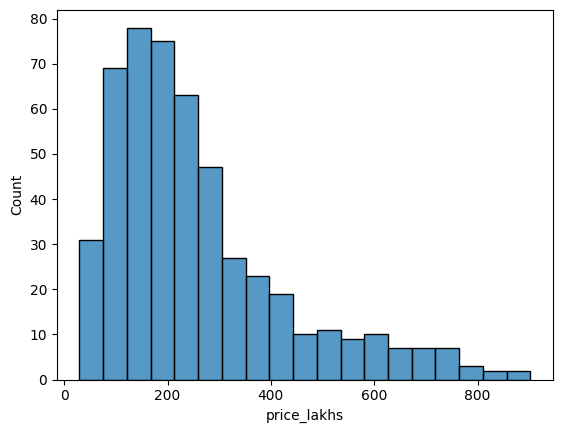

In [ ]:
sns.histplot(df['price_lakhs'])

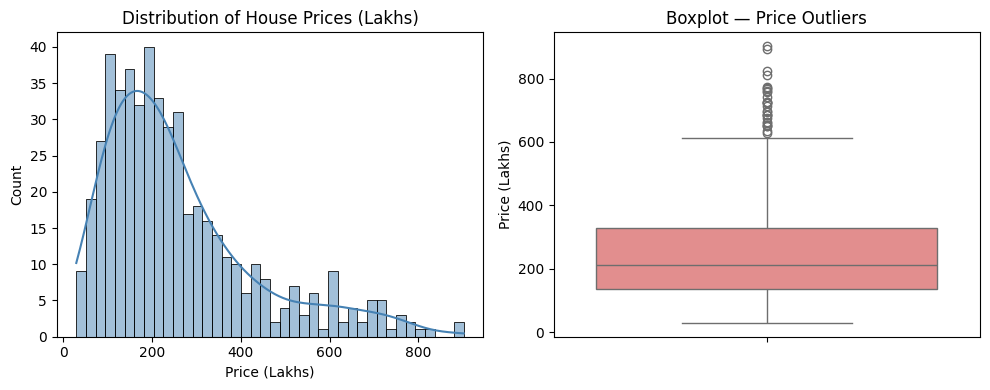

In [ ]:
# Distribution of house prices
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['price_lakhs'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of House Prices (Lakhs)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['price_lakhs'], color='lightcoral')
plt.title('Boxplot — Price Outliers')
plt.ylabel('Price (Lakhs)')

plt.tight_layout()
plt.show()

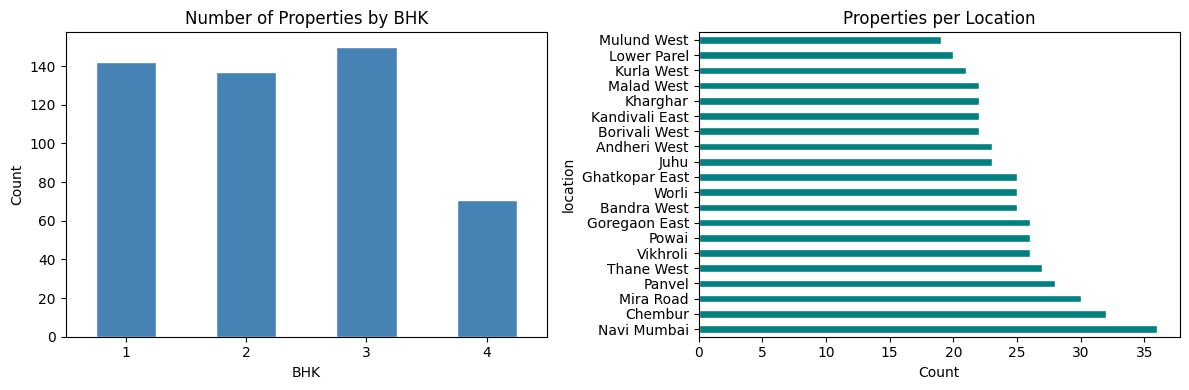

In [ ]:
# BHK and location frequency
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['bhk'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of Properties by BHK')
plt.xlabel('BHK')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['location'].value_counts().plot(kind='barh', color='teal', edgecolor='white')
plt.title('Properties per Location')
plt.xlabel('Count')

plt.tight_layout()
plt.show()

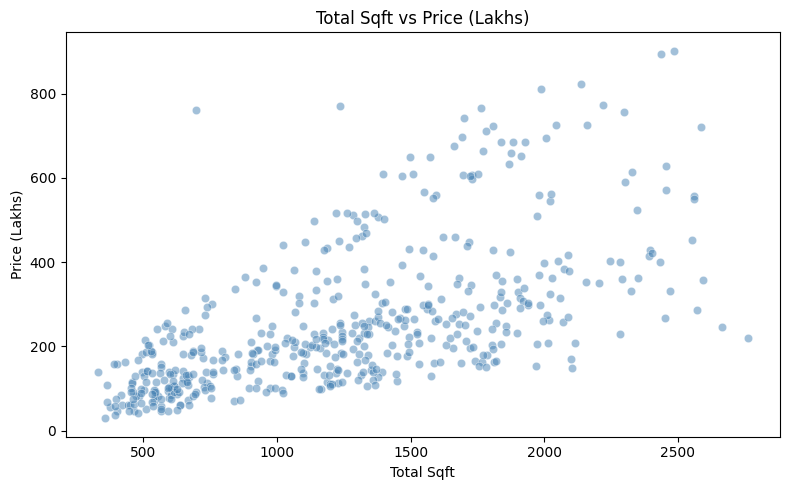

In [ ]:
# Sqft vs Price scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(x='total_sqft', y='price_lakhs', data=df,
                alpha=0.5, color='steelblue')
plt.title('Total Sqft vs Price (Lakhs)')
plt.xlabel('Total Sqft')
plt.ylabel('Price (Lakhs)')
plt.tight_layout()
plt.show()

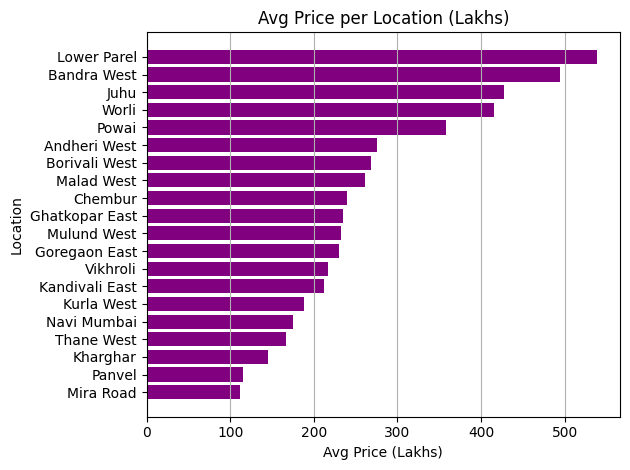

In [ ]:
loc_avg = df.groupby('location')['price_lakhs'].mean().sort_values()

#plt.figure(figsize=(10, 6))
plt.barh(loc_avg.index, loc_avg.values, color='purple')
plt.title('Avg Price per Location (Lakhs)')
plt.xlabel('Avg Price (Lakhs)')
plt.ylabel('Location')
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

**Conclusions taken:**

1. **Location is the biggest price driver** — Bandra West, Juhu and Worli are the costliest. Panvel and Mira Road are the most affordable.
2. **Price distribution is right skewed** — most properties fall between ₹40–200L with a few luxury outliers above ₹500L.
3. **2BHK and 3BHK dominate** — most common property types across Mumbai.
4. **Bigger the flat, higher the price** — clear positive correlation between sqft and price.
5. **Location premium exists** — some small flats in premium areas cost more than large flats in suburbs.
6. **4BHK in Bandra costs more than 4BHK in Panvel** — BHK alone doesn't decide price, location does.